# DQN — Lunar Lander


In [1]:
from agent import AgentDQN
from matplotlib import pyplot as plt
import gym
from jupyterthemes import jtplot
jtplot.style(theme='monokai', context='notebook', ticks=True, grid=False)
%matplotlib inline



env = gym.make('LunarLander-v2')
agent = AgentDQN(env, 
                 buffer_size=1_000_000, 
                 batch_size=64, 
                 tau=1e-3, 
                 gamma=0.99, 
                 learning_rate=0.001,# 5e-4, 
                 epsilon_decay=0.995, 
                 epsilon_min=0.01, 
                 epsilon=1.0)

/home/mortimer/.local/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:97: UserWarning: WARN: We recommend you to use a symmetric and normalized Box action space (range=[-1, 1]) https://stable-baselines3.readthedocs.io/en/master/guide/rl_tips.html
  logger.warn(
/home/mortimer/.local/lib/python3.10/site-packages/gym/core.py:200: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` instead.
  deprecation(


In [ ]:
history = agent.train(episodes=200, K=1, video_path='video') # inint K/10 N/10 G/-100
agent.Q_target.save_weights('leaky_lunar_lander_e200_target.pd')
agent.Q.save_weights('leaky_lunar_lander_e200.pd')
agent.buffer.save('dqn_lunar_lander.erb')

Training Agent:   0%|         | 1/200 [00:03<12:24,  3.74s/it, G=-19.6, S=-146, l=18, epsilon=0.134]/home/mortimer/.local/lib/python3.10/site-packages/gym/wrappers/record_video.py:75: UserWarning: WARN: Overwriting existing videos at /home/mortimer/Documents/Deep-Reinforcement-Learning/homework/hw3/video/lunar_lander_0 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
Training Agent:  34%|██▎    | 67/200 [21:56<36:54, 16.65s/it, G=-37.3, S=-194, l=40, epsilon=0.0962]

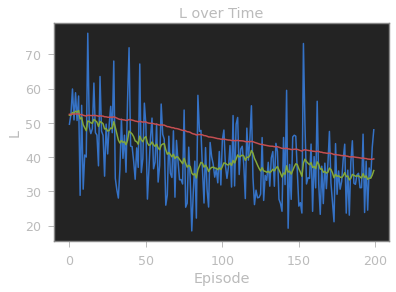

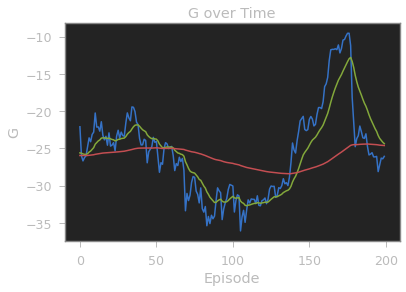

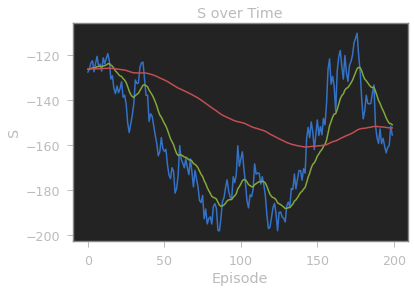

In [30]:
def smooth(Ls, h):
    x, soothed = Ls[1], []
    for l in Ls:
        x = h * x + (1 - h) * l
        soothed.append(x)
    return soothed

for name, vals in history.items():
    X = range(len(vals))
    plt.plot(X, vals)
    plt.plot(X, smooth(vals, h=0.9))
    plt.plot(X, smooth(vals, h=0.99))
    plt.title(f'{name.title()} over Time')
    plt.xlabel('Episode')
    plt.ylabel(name)
    plt.show()

In [26]:
import random

seed = 42 # 7 6 3
random.seed(seed)
env.seed(seed)
#O = env.reset(seed=seed)
#O = env.reset()
O = env.reset()

done = False
G, t, score = 0, 0, 0
Qs = []
Rs = []
Os = []
#agent.Q_target.load_weights('leaky_lunar_lander_e2000_target.pd')
#agent.Q.load_weights('leaky_lunar_lander_e2000.pd')
while not done:
    A = agent(O, sample=False)
    if t > 900:
        A = 0
    O, R, done, _ = env.step(A)
    Qs.append(agent.Q.predict(O[None,...]).tolist()[0])
    Os.append(O)
    env.render()
    G += agent.gamma**t * R
    score += R
    Rs.append(int(R))
    t += 1

In [29]:
print(agent.buffer[0])
print(agent.buffer[1])
#agent.buffer += [(O, A, R, O, 1)]
#print(agent.buffer[0])
#print(agent.buffer[1])
"""(array([ 0.26704064, -0.02784275,  0.86000395, -1.07954001, -0.99088401,
        0.8208831 ,  1.        ,  0.        ]), array(3, dtype=int32), array(-100.), array([ 0.26704064, -0.02784275,  0.86000395, -1.07954001, -0.99088401,
        0.8208831 ,  1.        ,  0.        ]), array(1.))"""

(array([ 0.70176637, -0.14756712, -0.31163394,  0.08195694,  2.00418687,
        0.94483393,  0.        ,  0.        ]), array(2, dtype=int32), array(-100.), array([ 0.70176637, -0.14756712, -0.31163394,  0.08195694,  2.00418687,
        0.94483393,  0.        ,  0.        ]), array(1.))
(array([ 0.26704064, -0.02784275,  0.86000395, -1.07954001, -0.99088401,
        0.8208831 ,  1.        ,  0.        ]), array(3, dtype=int32), array(-100.), array([ 0.26704064, -0.02784275,  0.86000395, -1.07954001, -0.99088401,
        0.8208831 ,  1.        ,  0.        ]), array(1.))


'(array([ 0.26704064, -0.02784275,  0.86000395, -1.07954001, -0.99088401,\n        0.8208831 ,  1.        ,  0.        ]), array(3, dtype=int32), array(-100.), array([ 0.26704064, -0.02784275,  0.86000395, -1.07954001, -0.99088401,\n        0.8208831 ,  1.        ,  0.        ]), array(1.))'

G -22 Score -355 R -100


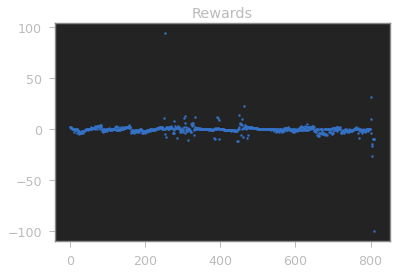

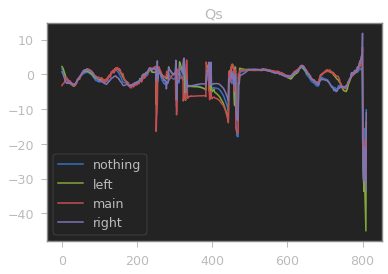

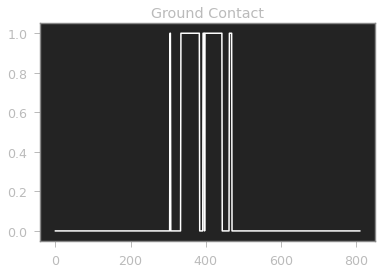

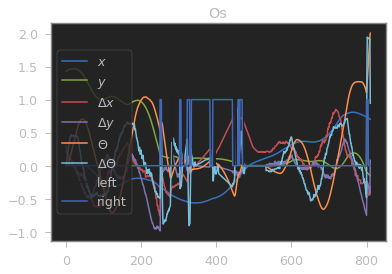

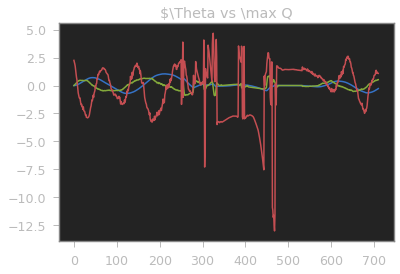

In [31]:
size = 5
print('G', int(G), 'Score', int(score), 'R', R)
#print(Qs)
plt.title('Rewards')
plt.scatter(range(t), Rs, s=size)
plt.show()
plt.title('Qs')
for Q in zip(*Qs):
    plt.plot(range(t), Q)
plt.legend(['nothing', 'left', 'main', 'right'])
plt.show()
plt.title('Ground Contact')
plt.plot(range(t), [O[6] == O[7] == 1 for O in Os], c='white')
#plt.scatter(range(t), [O[6] for O in Os], s=size)
#plt.scatter(range(t), [O[7] for O in Os], s=size)
plt.show()
plt.title('Os')
for Q in zip(*Os):
    plt.plot(range(t), Q)
plt.legend(['$x$', '$y$', '$\Delta x$', '$\Delta y$', '$\Theta$', 
            '$\Delta \Theta$', 'left', 'right'], loc='center left')
plt.show()

c = 100
plt.title('$\Theta vs \max Q')
plt.plot(range(t - c), [O[4] for O in Os[:-c]])
plt.plot(range(t - c), [O[5] for O in Os[:-c]])
plt.plot(range(t - c), [max(Q) for Q in Qs[:-c]])
plt.show()

<video alt="test" autoplay loop controls style="height: 300px;">
    <source src="home/mortimer/Documents/Deep-Reinforcement-Learning/homework/hw3/video/lunar_lander_0/rl-video-episode-0.mp4" type="video/mp4" />
</video>